# Day 047 · TA-Lib 技术指标
**TA-Lib** · 阶段 P2 · Python 量化工具栈

> 做技术分析,绕不开均线、相对强弱、快慢线这些技术指标。它们听着唬人,其实就是把每天的价格,加工成一个更好读的信号,比如把上蹿下跳的价格抹平成一条均线看大方向。这一节我们认识四个最常用的指标:均线 MA、相对强弱 RSI、快慢线 MACD、真实波幅 ATR,用真实的三一重工数据,每个都先给你讲清楚它在量什么、怎么读,再亲手算出来画成图。行业里有个标准工具箱叫 TA-Lib,一行就能调出一个指标;我们这节用 pandas 几行把它们复刻出来,既看懂背后的道理,又不用折腾它麻烦的安装,最后把一篮子指标拼成一张特征表,给选股和后面的机器学习当原料。

---

**课件生成日期:** 2026-06-14  ·  **建议学习时长:** 18 分钟

学习路径建议:1)先看视频建立直觉 → 2)阅读本 notebook 跑代码 → 3)看 PDF 课件复习要点 → 4)做自测题

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有需要的 Python 包,缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续下面的代码

> 这一格只在第一次跑要等几十秒,后面再开 notebook 就秒过。

In [1]:
# === 环境自检 + 自动安装(运行此单元格即可) ===
# 检测缺失的库 → 自动 pip 安装 → 注入中文字体 → 一行命令搞定
import importlib
import subprocess
import sys
import os

REQUIRED = ["baostock", "matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels", "yfinance"]
PIP_NAME = {
    "sklearn": "scikit-learn",
    "cv2": "opencv-python",
    "PIL": "Pillow",
    "bs4": "beautifulsoup4",
    "yaml": "PyYAML",
}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))

if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,正在自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置(让 matplotlib 不出乱码) ===
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

CJK_FONT_PATHS = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",  # Linux/WSL
    "C:/Windows/Fonts/msyh.ttc",                               # Windows 微软雅黑
    "C:/Windows/Fonts/simhei.ttf",                             # Windows 黑体
    "/System/Library/Fonts/PingFang.ttc",                      # macOS 苹方
    "/System/Library/Fonts/STHeiti Medium.ttc",                # macOS 黑体
]
for p in CJK_FONT_PATHS:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP", "Microsoft YaHei",
                                    "PingFang SC", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪 — 现在可以跑下面的代码单元格")


✓ 所有 9 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪 — 现在可以跑下面的代码单元格


## 学习目标

- 理解技术指标的本质:把价格加工成更好读的信号,而不是什么神秘的预测公式
- 看懂四个常用指标在量什么:MA 看趋势、RSI 看冷热、MACD 看转折、ATR 看波动
- 会用 pandas 几行算出 MA/RSI/MACD/ATR,并知道用 TA-Lib 各是哪一行
- 会把一篮子指标拼成一张特征表,给选股或机器学习当输入原料
- 知道指标天生滞后、会骗人,绝不能只凭单一指标做决定

## 历史背景:老吴照着一个指标买卖,结果被来回扇耳光

老吴学了点技术分析,听人说 RSI 超过 70 就是超买该卖、低于 30 就是超卖该买,如获至宝。他盯着一只票,RSI 一过 70 赶紧卖,结果票还在涨,踏空一大段;RSI 一跌破 30 赶紧买,结果继续跌,套得更深。来回被扇耳光,他纳闷:指标不是挺科学的吗,怎么照着做反而亏?后来一位老手点醒他:指标不是水晶球,它只是把价格换个角度给你看。RSI 高只说明最近涨得急,在强势的大牛行情里,它能在 70 以上待很久,你一看到 70 就卖,等于把利润最肥的一段让出去。任何单一指标都有它失灵的场合,真正的用法是几个指标互相印证、再结合大势判断,而不是把某一个当圣旨闭眼执行。老吴这才明白:指标是帮你看清的工具，做决定的还得是你自己的脑子。



## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. 技术指标是什么:把价格加工成更好读的信号

别被『技术指标』四个字唬住。它的本质特别朴素:拿每天的价格,做一点简单的加减平均,变成一个更容易看出门道的数。比如价格每天上蹿下跳看不清方向,把最近 20 天的收盘价一平均,连成一条线,大方向就出来了,这就是最简单的指标,均线。所以指标不是预测未来的神秘公式,它只是把原始价格换个角度、换个形式呈现给你,帮你看得更清楚。理解了这一点,后面所有指标你都不会怕。


### 2. MA 均线:最近 N 天的平均价,看趋势

均线是最基础的指标:把最近 N 天的收盘价加起来求个平均,再把每天的平均值连成线。5 日均线代表最近一周的平均成本、20 日代表一个月、60 日代表3 个月。它的作用是把每天的噪声抹平,让你看清大方向,价格站在均线上方往往偏强,跌破往往偏弱;短期均线上穿长期均线(金叉)、下穿(死叉),是最经典的趋势信号。算起来就一句:收盘价做个滚动平均。


### 3. RSI 相对强弱:0 到 100 的冷热温度计

RSI 把最近一段时间『上涨的劲』和『下跌的劲』做个比较,换算成一个 0 到 100 的数。你就把它当成一支温度计:数越高说明最近涨得越猛、越『热』,通常 70 以上叫超买(偏热);数越低说明跌得越狠、越『冷』,30 以下叫超卖(偏冷)。它帮你感知短期的过热或过冷。但务必记住,热不等于马上要跌,强势行情里 RSI 能在高位待很久,它只是个参照,不是买卖命令。


### 4. MACD 快慢线:两条均线的差,看趋势转折

MACD 用一快一慢两条均线(快的反应灵敏、慢的反应迟钝),算它们的差。当快线从下往上穿过慢线、两者的差由负转正,往往意味着趋势在由弱转强;反过来则由强转弱。它还画成一根根红绿柱,柱子由绿翻红、由短变长,是动能增强的直观信号。MACD 的长处是抓趋势的转折点,比单看价格更早给你一点提示,但同样,它也会发假信号,得结合别的判断。


### 5. 批量算一篮子指标:给选股和机器学习当『特征』

真正做量化,很少只看一个指标,而是一口气算出一大堆,均线、RSI、MACD、真实波幅 ATR(衡量这只票每天大概晃多少钱)等等,把它们拼成一张表,每一列是一个指标,每一行是一天。这张表就叫『特征表』,是后面做选股打分、甚至喂给机器学习模型的原料。这也是行业标准库 TA-Lib 最大的价值:一百多个指标一键调用,一行一个,批量产出特征又快又省事。


## 实操:技术指标 — MA 均线 / RSI 相对强弱 / MACD 快慢线 / ATR 真实波幅,pandas 复刻 + 拼成特征表(对照 TA-Lib 一行写法)

下面这段代码跟视频里讲解的 highlights 是一致的,可以**直接 Run All** 看结果。

**依赖安装:**
```bash
pip install pandas numpy matplotlib yfinance akshare statsmodels
```


==== 0. 拉三一重工日线(开高低收)====
从本地 CSV 读取:/mnt/d/huizi_ai_project/ai_course_video/out/notebook/data/D047_talib.csv
三一重工 日线 726 条  2022-01-04 → 2024-12-31

==== 1. MA 均线(rolling 求平均)====
TA-Lib 一行就是:talib.MA(close, 20)
            close    ma5   ma20   ma60
date                                  
2024-12-30  16.13  16.02  16.11  16.98
2024-12-31  15.94  16.03  16.08  16.94

==== 2. RSI 相对强弱(涨的劲 vs 跌的劲)====
TA-Lib 一行就是:talib.RSI(close, 14)
最新 RSI = 38.8（>70 偏热 / <30 偏冷)

==== 3. MACD(快线 EMA12 − 慢线 EMA26,再求差离柱)====
TA-Lib 一行就是:macd, signal, hist = talib.MACD(close)
             macd  signal   hist
date                            
2024-12-30 -0.232  -0.284  0.051
2024-12-31 -0.224  -0.272  0.048

==== 4. ATR 真实波幅(衡量波动,常用来定止损)====
TA-Lib 一行就是:talib.ATR(high, low, close, 14)
最新 ATR = 0.29 元（这只票最近平均每天波动约这么多)

==== 5. 一篮子指标特征表(最后 3 天)====
            close    ma5   ma20   ma60  rsi14  macd  signal  hist  atr14
date                                                                    
2024-12-27  16.08

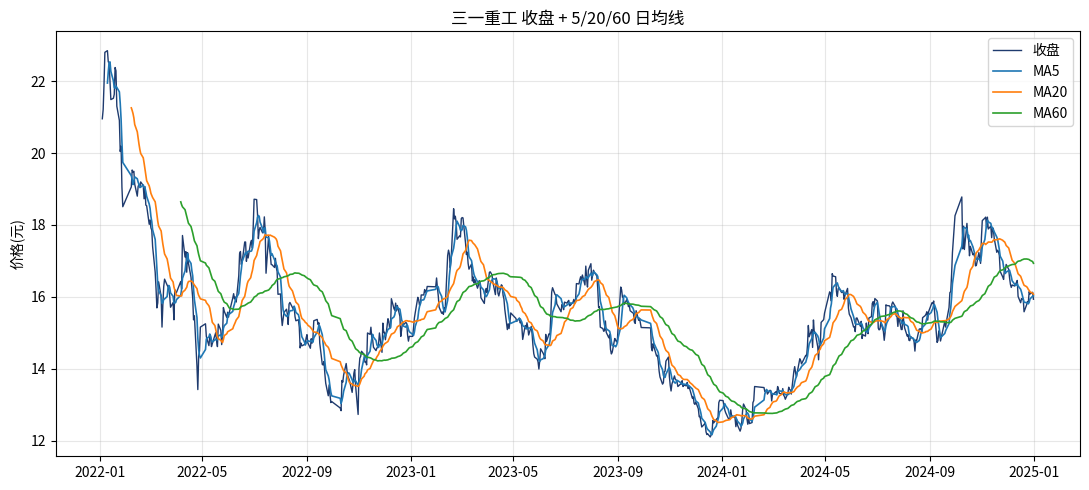

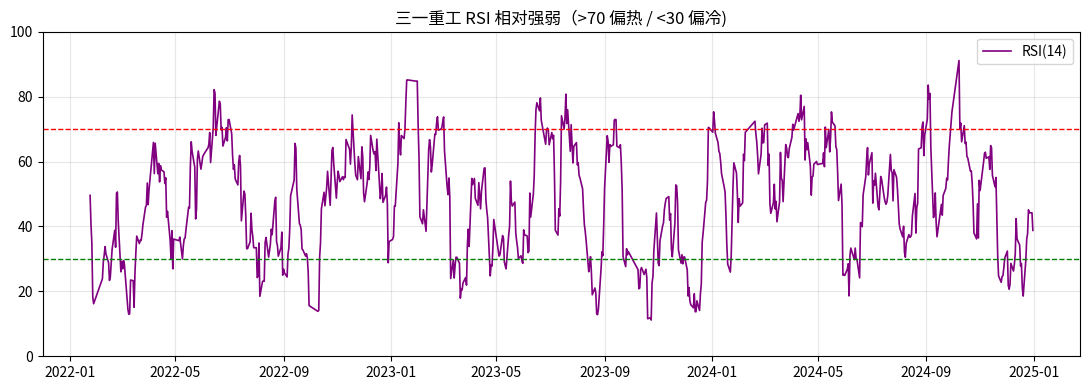

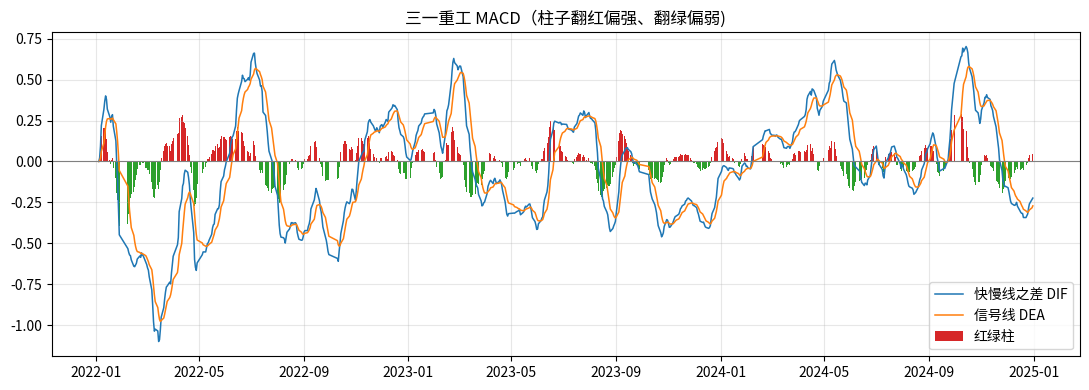

In [2]:
# day_047_indicators.py — 技术指标:均线 MA / 相对强弱 RSI / 快慢线 MACD / 真实波幅 ATR
# 技术指标 = 把每天的价格,加工成更好读的信号。行业标准库是 TA-Lib(C 写的、快,但装起来麻烦)
# 这一节我们用 pandas 几行把核心指标复刻出来(既看懂原理、又不折腾安装);真名上屏:RSI / MACD / ATR
# 装好 TA-Lib 后,这些其实都是一行:talib.RSI(close,14) / talib.MACD(close) / talib.ATR(high,low,close,14)
import pandas as pd
import matplotlib.pyplot as plt
import baostock as bs

def _data_path(_name):
    # 铁律62:data/ 放在 notebook 文件夹里。仓库根(run_lab)存取 out/notebook/data/;
    # 原版 notebook 在 out/notebook/ 用 data/;中国版在 out/notebook/cn/ 用 ../data/
    from pathlib import Path as _P
    _here = _P.cwd()
    for _b in [_here/'data', _here/'..'/'data', _here/'out'/'notebook'/'data', _here/'..'/'..'/'data', _here/'..'/'..'/'..'/'data']:
        if (_b/_name).exists():
            return str(_b/_name)
    if (_here/'out'/'notebook').exists():
        _t = _here/'out'/'notebook'/'data'
    elif _here.name == 'cn':
        _t = _here/'..'/'data'
    else:
        _t = _here/'data'
    _t.mkdir(parents=True, exist_ok=True)
    return str(_t/_name)

pd.set_option('display.width', 160)
plt.rcParams['axes.unicode_minus'] = False
CODE, NAME = 'sh.600031', '三一重工'
START, END = '2022-01-01', '2024-12-31'

# ==== 0. 拉日线(开高低收):CSV 优先,baostock 兜底,拉完存 CSV ====
print('==== 0. 拉三一重工日线(开高低收)====')
import os as _os
_csv = _data_path('D047_talib.csv')
if _os.path.exists(_csv):
    df = pd.read_csv(_csv)
    print(f'从本地 CSV 读取:{_csv}')
else:
    lg = bs.login()
    if lg.error_code != '0':
        raise RuntimeError(f'baostock 登录失败:{lg.error_msg}')
    rs = bs.query_history_k_data_plus(CODE, 'date,open,high,low,close', start_date=START,
                                      end_date=END, frequency='d', adjustflag='2')
    rows = []
    while rs.error_code == '0' and rs.next():
        rows.append(rs.get_row_data())
    bs.logout()
    df = pd.DataFrame(rows, columns=['date', 'open', 'high', 'low', 'close'])
    df.to_csv(_csv, index=False)
    print(f'已从 baostock 拉取并存成 CSV:{_csv}')
df['date'] = pd.to_datetime(df['date'])
for c in ['open', 'high', 'low', 'close']:
    df[c] = pd.to_numeric(df[c])
df = df.set_index('date').sort_index()
close, high, low = df['close'], df['high'], df['low']
print(f'{NAME} 日线 {len(df)} 条  {df.index[0].date()} → {df.index[-1].date()}')

# ==== 1. MA 均线:最近 N 天收盘价的平均,抹平上蹿下跳看大方向 ====
print('\n==== 1. MA 均线(rolling 求平均)====')
for w in (5, 20, 60):
    df[f'ma{w}'] = close.rolling(w).mean()
print('TA-Lib 一行就是:talib.MA(close, 20)')
print(df[['close', 'ma5', 'ma20', 'ma60']].tail(2).round(2).to_string())

# ==== 2. RSI 相对强弱:0-100 的温度计,>70 偏热(超买)、<30 偏冷(超卖)====
print('\n==== 2. RSI 相对强弱(涨的劲 vs 跌的劲)====')
delta = close.diff()
gain = delta.clip(lower=0)        # 上涨那部分
loss = -delta.clip(upper=0)       # 下跌那部分(取正)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df['rsi14'] = 100 - 100 / (1 + rs)
print('TA-Lib 一行就是:talib.RSI(close, 14)')
print(f'最新 RSI = {df["rsi14"].iloc[-1]:.1f}（>70 偏热 / <30 偏冷)')

# ==== 3. MACD 快慢线:两条快慢均线的差,看趋势的转折 ====
print('\n==== 3. MACD(快线 EMA12 − 慢线 EMA26,再求差离柱)====')
ema12 = close.ewm(span=12, adjust=False).mean()
ema26 = close.ewm(span=26, adjust=False).mean()
df['macd'] = ema12 - ema26                       # 快慢线之差(DIF)
df['signal'] = df['macd'].ewm(span=9, adjust=False).mean()  # 信号线(DEA)
df['hist'] = df['macd'] - df['signal']           # 红绿柱(柱子翻红=转强)
print('TA-Lib 一行就是:macd, signal, hist = talib.MACD(close)')
print(df[['macd', 'signal', 'hist']].tail(2).round(3).to_string())

# ==== 4. ATR 真实波幅:这只票每天大概晃多少钱,衡量波动 ====
print('\n==== 4. ATR 真实波幅(衡量波动,常用来定止损)====')
prev_close = close.shift(1)
tr = pd.concat([high - low, (high - prev_close).abs(), (low - prev_close).abs()], axis=1).max(axis=1)
df['atr14'] = tr.rolling(14).mean()
print('TA-Lib 一行就是:talib.ATR(high, low, close, 14)')
print(f'最新 ATR = {df["atr14"].iloc[-1]:.2f} 元（这只票最近平均每天波动约这么多)')

# ==== 5. 把一篮子指标拼成一张『特征表』(给选股/机器学习当原料)====
print('\n==== 5. 一篮子指标特征表(最后 3 天)====')
feat = df[['close', 'ma5', 'ma20', 'ma60', 'rsi14', 'macd', 'signal', 'hist', 'atr14']]
print(feat.tail(3).round(2).to_string())
print(f'\n一次算出 {feat.shape[1]} 个指标列,{feat.dropna().shape[0]} 个完整交易日的特征')

# ==== 6. 画图:价格+均线 / RSI / MACD ====
print('\n==== 6. 画三张图:价格+均线 / RSI / MACD ====')
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df.index, close, label='收盘', lw=1, color='#1f3b6e')
for w in (5, 20, 60):
    ax.plot(df.index, df[f'ma{w}'], label=f'MA{w}', lw=1.2)
ax.set_title(f'{NAME} 收盘 + 5/20/60 日均线'); ax.set_ylabel('价格(元)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.savefig('ma.png', dpi=120)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df.index, df['rsi14'], color='purple', lw=1.2, label='RSI(14)')
ax.axhline(70, color='red', ls='--', lw=1); ax.axhline(30, color='green', ls='--', lw=1)
ax.set_title(f'{NAME} RSI 相对强弱（>70 偏热 / <30 偏冷)'); ax.set_ylim(0, 100)
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.savefig('rsi.png', dpi=120)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df.index, df['macd'], label='快慢线之差 DIF', lw=1.1)
ax.plot(df.index, df['signal'], label='信号线 DEA', lw=1.1)
colors = ['#d62728' if h >= 0 else '#2ca02c' for h in df['hist']]
ax.bar(df.index, df['hist'], color=colors, width=1.0, label='红绿柱')
ax.axhline(0, color='gray', lw=0.8)
ax.set_title(f'{NAME} MACD（柱子翻红偏强、翻绿偏弱)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.savefig('macd.png', dpi=120)

print('\n[done] MA / RSI / MACD / ATR 一篮子指标算完,特征表 + 3 张图已生成')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| A 股 | sh.600031 | 三一重工算 MA5/20/60 + RSI14 + MACD + ATR14,拼成一张指标特征表 |
| 趋势判断 |  | 用均线金叉死叉 + MACD 红绿柱翻转互相印证,判断趋势由弱转强还是转弱 |
| 冷热感知 |  | RSI 升到 70 以上提示短期偏热、跌破 30 提示偏冷,作为一个参照而非买卖命令 |
| 风控定止损 |  | 用 ATR 衡量这只票每天大概波动多少,据此设一个不容易被正常波动扫到的止损 |


## 常见坑

### ⚠ 01. 只凭单一指标买卖,被来回打脸

看到 RSI 过 70 就卖、跌破 30 就买,在强势或弱势的单边行情里会被反复扇耳光。任何单一指标都有失灵的场合,正确做法是几个指标互相印证、再结合大势,绝不把某一个当圣旨闭眼执行。

### ⚠ 02. 忘了指标天生滞后

几乎所有指标都是用过去的价格算出来的,本质上是『后视镜』,它告诉你过去发生了什么,不是预言未来。均线尤其滞后,等金叉出现,趋势往往已经走了一段。用指标时心里要清楚这份滞后,别指望它精准抄底逃顶。

### ⚠ 03. TA-Lib 装不上就卡死在第一步

行业标准库 TA-Lib 是 C 语言写的,直接 pip 经常装不上,需要先装它的底层 C 库,新手最容易卡在这。两条出路:要么按官方说明先装 C 库再装 talib,要么用纯 Python 的替代品 pandas-ta,或者像本节用 pandas 几行自己实现核心指标,绕开安装难题。

### ⚠ 04. 指标参数照搬默认,不理解含义

RSI 默认 14 天、MACD 默认 12/26/9,这些数字不是天定的,是经验值。不理解参数含义就乱改或盲从,容易得出莫名其妙的结论。先搞懂每个参数在控制『看多长的窗口』,再决定要不要调。

### ⚠ 05. 特征表里的 NaN 直接喂进模型

指标算出来,前面几十天因为数据不够会是空值(NaN),比如 60 日均线前 59 天都没有。把带 NaN 的特征表直接拿去选股或喂模型会报错或失真,记得先把开头不完整的行去掉(dropna)再用。

## 实战 SOP · 用技术指标的几条规矩

1. 把指标理解成『把价格换个角度看的信号』,不是预测未来的水晶球
2. 永远多个指标互相印证 + 结合大势,绝不只凭单一指标闭眼买卖
3. 心里清楚指标天生滞后(用过去价格算的),别指望精准抄底逃顶
4. TA-Lib 装不上就用 pandas-ta 或自己用 pandas 实现,别卡在安装上
5. 拼成特征表后先 dropna 去掉开头不完整的行,再拿去选股或喂模型

> 把这段打印贴在你电脑边,执行 1000 次它会回报你。

## 总结 · 你应该带走的

2. 技术指标的本质 = 把每天的价格做点简单加工,变成更好读的信号,不是神秘预测公式。
3. MA 均线 = 最近 N 天平均价,抹平噪声看趋势;金叉死叉是经典信号。
4. RSI = 0 到 100 的冷热温度计,>70 偏热、<30 偏冷,是参照不是命令。
5. MACD = 一快一慢两条均线的差 + 红绿柱,擅长提示趋势的转折。
6. ATR = 这只票每天大概波动多少,常用来设一个合理的止损。
7. 把一篮子指标拼成特征表(记得 dropna),是选股和机器学习的原料;TA-Lib 一键批量产出。

## 自测题

**Q1.** 用一句大白话解释:为什么说技术指标不是『预测未来的公式』,而是『把价格换个角度看』?

**Q2.** RSI 升到 75,老吴说『超买了赶紧卖』。结合本课的故事,说说这么做可能错在哪。

**Q3.** MA、RSI、MACD、ATR 四个指标各自主要量的是什么?各用四个字概括。

**Q4.** 为什么把指标拼成特征表后,要先 dropna 再拿去用?开头的 NaN 是怎么来的?

把答案写下来,3 天后再回看。

## 下一节预告

**Day 048 · SciPy 统计工具箱** (SciPy Stats)

技术指标帮我们把价格变成信号,但要严肃地研究收益的规律,得请出统计学的工具。下一节用 SciPy 统计工具箱,看清一个反直觉的真相:股票收益根本不是教科书说的『正态分布钟形曲线』,它的尾巴特别厚,也就是暴涨暴跌,比理论上常见得多。

## 推荐阅读

- Murphy《Technical Analysis of the Financial Markets》(1999/NYIF)— 技术分析的圣经,MA/RSI/MACD 等指标的权威讲解。
- Kaufman《Trading Systems and Methods》(2013/Wiley)— 把各类指标和交易系统讲透的大部头,实证扎实。
- TA-Lib 官方文档(ta-lib.org)— 行业标准库,150+ 指标的函数清单和参数说明。
- pandas-ta 文档(github.com/twopirllc/pandas-ta)— 纯 Python 的指标库,装起来比 TA-Lib 省事,接口贴合 pandas。
- Wilder《New Concepts in Technical Trading Systems》(1978/Trend Research)— RSI 和 ATR 的原始出处,经典中的经典。